In [2]:
# Install openpyxl and suppress the output
!pip install openpyxl > /dev/null 2>&1

### **Teilnehmer:** 
 - ✔	**Zena Florinesse Ndjiki Mbassin**
 - ✔	**Duchelle Loko Tchapmeni Houevi**
 - ✔	**N'Guessan David Totokra**
 - ✔	**Wilfried Naoussi**


## Verfahren:

Für die Analyse des Datensatzes der Wohnungsbaugesellschaft (WBG) und die Untersuchung der damit verbundenen Fragestellung werden wir verschiedene Schritte durchführen:
1. **Einleitung**
In diesem Abschnitt geben wir eine kurze Beschreibung des Themas und der Fragestellung. Ziel ist es, die Einflussfaktoren auf die Mietkosten pro Quadratmeter zu analysieren und zu bewerten.

2. **Datenbeschaffung und -aufbereitung**
Hier beschreiben wir die Datenquelle und die Datenaufbereitung. Dieser Schritt umfasst auch die Anwendung von One-Hot-Encoding für kategoriale Variablen, um diese in ein für die Analyse geeignetes Format zu bringen.

3. **Deskriptive Statistiken**
Das Ziel dieses Schrittes ist es, die Daten zu analysieren und die Verteilungen zu visualisieren.

4. **Visualisierung**
In diesem Schritt erstellen wir Streudiagramme oder Heatmaps, um die Zusammenhänge zwischen den Mietkosten pro Quadratmeter und verschiedenen Merkmalen zu visualisieren. Dies umfasst die Untersuchung der Auswirkungen von Wohngebiet, Ausstattung (Dusche, Badewanne, Aufzug, Balkon/Terrasse), Geschoss und Wohndauer. Eine detaillierte Korrelationsanalyse basierend auf der Korrelationsmatrix wird ebenfalls durchgeführt.

5. **Datenmodellierung**
Hier wählen und wenden wir Modellierungstechniken für die (out-of-sample) Prognose an. Dies umfasst die Anwendung einer linearen Regression zur Untersuchung linearer Zusammenhänge sowie von Entscheidungsbäumen und Random Forest zur Identifizierung komplexerer Zusammenhänge. Anschließend diskutieren wir die Wahl der geeigneten Strategie zur Verbesserung der Modellgenauigkeit und zur Vermeidung von Überanpassung.

6. **Prognoseevaluation**
In diesem Schritt evaluieren wir die Prognosemodelle und interpretieren die Ergebnisse. Wir verwenden Hyperparameter-Tuning und Modellbewertung anhand von Metriken wie MSE, R²-Score, RMSE, MAE und MAPE für die Regressionsanalyse.

7. **Zusammenfassung und Ausblick**
Abschließend fassen wir die Ergebnisse der gesamten Analyse zusammen und geben einen Ausblick auf mögliche weitere Untersuchungen und Anwendungen der gewonnenen Erkenntnisse.


## **Einleitung zur Analyse von Wohnungswirtschaft der WBG**

In dieser Analyse untersuchen wir einen Immobiliendatensatz von WBG, der Informationen über verschiedene Eigenschaften von Wohnungen enthält. Unser Hauptziel ist es, die Mietkosten pro Quadratmeter vorherzusagen. Die Mietkosten pro Quadratmeter wurden als Zielvariable ausgewählt, da sie ein zentrales Kriterium für Mieter und Vermieter von WBG darstellen und eine direkte Auswirkung auf die Wohnungswahl und die wirtschaftliche Planung haben. Die Vorhersage der Mietkosten pro Quadratmeter ermöglicht es uns, wertvolle Einblicke in den Immobilienmarkt zu gewinnen und potenzielle Preisschwankungen zu identifizieren.

Um die Mietkosten pro Quadratmeter genau vorherzusagen, haben wir eine Reihe von Merkmalen ausgewählt, die wir als relevant und potenziell einflussreich für die Mietkosten betrachten.

Die zentrale Fragestellung dieser Analyse lautet: **Inwiefern beeinflussen Kriterien wie Raumanzahl, Geschoss, Ausstattungen (Dusche,
Badewanne, Aufzug, Balkon/Terrasse), Wohngebiet und Wohndauer die Mietkosten pro
Quadratmeter?**

Um diese Frage zu beantworten, haben wir die folgenden Hypothesen formuliert:
- H1: Die Mietkosten variieren je nach Wohngebiet. In beliebten Wohngegenden oder in Gebieten mit guter Infrastruktur sind die Preise oft höher.
- H2:  Das Vorhandensein von Ausstattungsmerkmalen wie Dusche, Badewanne, Aufzug, Balkon/Terrasse korreliert mit höheren Mietkosten pro Quadratmeter.
- H3: Wohnungen, in denen Mieter bereits länger wohnen, haben möglicherweise niedrigere Mietkosten
  pro Quadratmeter im Vergleich zu Wohnungen mit kürzerer Wohndauer.

Durch die Untersuchung dieser Hypothesen hoffen wir, die Faktoren, die die Mietkosten pro Quadratmeter beeinflussen, besser zu verstehen und so genauere Modelle zur Vorhersage der Mietkosten zu erstellen.



## **Erklärung der Bibliothek**

**Pandas (pd)**: ist eine Bibliothek, die für die Datenmanipulation (zum Beispiel laden,bearbeiten,bereinigen...) und -analyse verwendet wird.Es bietet einfach zu handhabende Datenstrukturen wie DataFrame und Series.

**Seaborn (sns)**: Seaborn ist eine Python-Datenvisualisierungsbibliothek, die auf matplotlib basiert. Es bietet eine High-Level-Schnittstelle zum Zeichnen attraktive und aussagekräftige statistische Grafiken(zum Beispiel Boxplot).

**Matplotlib**: ist eine Bibliothek zur Erstellung von statischen, animierten und interaktiven Visualisierungen in Python wie zum Beispiel Diagrammen und Erstellung von Elemente wie Titeln, Beschriftungen, Legenden. es git auch Funktion wie **subplots**, die eine Figur und eine oder mehrere Achsen (Subplots)  erstellt. Sie wird verwendet, um mehrere Diagramme in einer einzigen Abbildung zu platzieren und bietet eine einfache Möglichkeit, komplexe Layouts von Plots zu erstellen.

**Numpy (np)**: ist eine Bibliothek für wissenschaftliches Rechnen in Python. Sie bietet Unterstützung für Arrays und viele mathematische Funktionen.

**Scikit-Learn**: ist eine Bibliothek für maschinelles Lernen in Python. Damit kann man vershiedene Modellen erstellen:
**Lineares Regressionsmodell**: wird verwendet, um die linearen Beziehungen zwischen den Variablen zu modellieren
**ColumnTransformer**: Ein Modul aus Scikit-Learn, das verschiedene Vorverarbeitungsschritte auf bestimmte Spalten eines Datenrahmens anwendet.
**OneHotEncoder**: Ein Modul aus Scikit-Learn zur Durchführung von One-Hot-Encoding, einer Methode zur Umwandlung kategorischer Daten in ein numerisches Format, das für maschinelle Lernmodelle geeignet ist.
**RandomForestRegressor**: Ein Modell aus der Bibliothek Scikit Learn, das Random Forests für die Regression verwendet. Es kombiniert die Vorhersagen mehrerer Entscheidungsbäume zur Verbesserung  der Genauigkeit.

Außerdem bietet Scikit-Learn auch **Funktion train_test_split** um den Datensatz in Trainings- und Testdaten aufzuteilen, was für die Modellvalidierung wichtig ist.

Noch dazu bietet Scikit-Learn **Metriken zur Bewertung von Modellen**
**mean_squared_error (MSE)**: Misst die durchschnittlichen quadratischen Fehler.
**r2_score**: Bestimmtheitsmaß, das den Anteil der Varianz erklärt, der durch das Modell erklärt wird.
**mean_absolute_percentage_error (MAPE)**: Misst die durchschnittlichen absoluten prozentualen Fehler.
**median_absolute_error**: Berechnet den mittleren absoluten Medianfehler, der den mittleren Fehler zwischen den vorhergesagten und tatsächlichen Werten darstellt.

**DecisionTreeRegressor (DTR)**: ist eine Klasse, die einen Entscheidungsbaum für die Regression implementiert. Entscheidungsbäume sind eine Art von Modell, das hierarchische Entscheidungen trifft, um eine Vorhersage zu treffen.

**plot_tree**: ist eine Funktion, die eine grafische Darstellung des Entscheidungsbaums erstellt. Sie zeigt die Struktur des Baums, einschließlich der getroffenen Entscheidungen und Unterteilungen.

**export_text**: Mit dieser Funktion können wir den Entscheidungsbaum in Textform anzeigen lassen. Diese Funktion ist nützlich, um die Struktur und Entscheidungensbaum in einem leicht lesbaren Textformat zu verstehen.

In [3]:
import pandas as pd  # Importieren der Pandas-Bibliothek zur Datenmanipulation
import seaborn as sns  # Importieren der Seaborn-Bibliothek für die Datenvisualisierung
import matplotlib.pyplot as plt  # Importieren der Matplotlib-Bibliothek zur Erstellung von Diagrammen
import numpy as np  # Importieren der NumPy-Bibliothek für numerische Berechnungen

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import (
    LinearRegression,
)  # Importieren des linearen Regressionsmodells aus Scikit-Learn
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)  # Importieren der Funktionen zur Datenaufteilung und Modellbewertung aus Scikit-Learn
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)  # Importieren verschiedener Metriken zur Bewertung von Modellen aus Scikit-Learn

from sklearn.tree import (
    DecisionTreeRegressor as DTR,
    plot_tree,
    export_text,
)  # Importieren der Entscheidungsbaum-Klassen und Funktionen zur Visualisierung und Darstellung aus Scikit-Learn

from matplotlib.pyplot import (
    subplots,
)  # Importieren der subplots-Funktion aus Matplotlib

## **Aufbereitung des Datensatzes**
Hier wollen wir uns mit der Aufbereitung unseres Datensatzes beschäftigen. Konkret wollen wir folgende Schritte durchführen:

- Überprüfung auf Fehlwerte: 
- Bereinigung von Fehlwerten: 
- Überprüfung und Bereinigung von Doppelwerten

### **Daten laden**

Das erlaubt es uns, die Daten in Python zu untersuchen und zu bearbeiten. Zusätzlich unterstützt uns das Laden der Daten dabei, einen Überblick über deren Aufbau zu erhalten und sicherzustellen, dass sie korrekt eingelesen wurden. Dies ist von besonderer Bedeutung für unsere Analyse, um sicherzustellen, dass wir mit den geeigneten Daten arbeiten und sie durchdringen können, bevor wir weitere Auswertungen vornehmen.

In [4]:
# Dateiname des Datensatzes
FILENAME_DATASET = "WBG_Datensatz.xlsx"

# Datensatz laden
raw_data = pd.read_excel(FILENAME_DATASET)

# Anzeige der ersten Zeilen des Datensatzes für einen schnellen Überblick
raw_data.head()

,Einheit,Haus,Wohnung,Wohngebiet,Geschoss,Wohnfläche,Raumanzahl,Dusche,Wanne,Aufzug,...,Einstufung Mietkosten,Geschlecht,Generation,Altereinstufung_Einzug,Wohndauer in Monaten,Mieteralter_Einzug,Einzug,Personenanzahl,Haustier,Mahnverfahren
0,1,1,1,Hohenstücken,Erdgeschoss,65.83,3,nein,ja,nein,...,3,M,8,3,544,37,1978-12-01,1,nein,nein
1,1,1,2,Hohenstücken,Erdgeschoss,66.23,3,nein,ja,nein,...,3,W,7,2,544,26,1978-12-01,1,nein,nein
2,1,1,3,Hohenstücken,1. Obergeschoss,65.83,3,nein,ja,nein,...,3,M,7,5,152,60,2011-07-01,2,nein,nein
3,1,1,4,Hohenstücken,1. Obergeschoss,93.10,5,nein,ja,nein,...,5,M,7,5,128,60,2013-08-01,3,ja,nein
4,1,1,5,Hohenstücken,2. Obergeschoss,65.83,3,nein,ja,nein,...,3,M,8,3,416,39,1989-08-01,1,nein,nein


### **Jetzt zeigen wir die Anzahl der Zeilen und Spalen an**
Wir geben die Anzahl der Zeilen und Spalten aus, um die Dimensionen des Datensatzes zu erfassen. Dies ermöglicht uns, einen Eindruck davon zu bekommen, wie viele Datenpunkte (Zeilen) und Attribute (Spalten) vorhanden sind.

In [5]:
# Dimension des Datensatzes anzeigen lassen
nSpalten = raw_data.shape[1]
nZeilen = raw_data.shape[0]

print(f"Der Datensatz hat {nZeilen} Zeilen und {nSpalten} Spalten.")

Der Datensatz hat 6424 Zeilen und 21 Spalten.


**Aus dem Ergebnis ist es zu bemerken , dass die Datensatz aus 6424 Beobachtungen und 21 Variablen besteht**

### **Anzeige der Spaltennamen des DataFrames**
ist wichtig, um einen schnellen Überblick über die verfügbaren Variablen zu haben

In [6]:
# Anzeigen der Spaltennamen des DataFrames 'raw_data'
raw_data.columns

Index(['Einheit', 'Haus', 'Wohnung', 'Wohngebiet', 'Geschoss', 'Wohnfläche',
       'Raumanzahl', 'Dusche', 'Wanne', 'Aufzug', 'Balkon/Terasse',
       'Einstufung Mietkosten', 'Geschlecht', 'Generation',
       'Altereinstufung_Einzug', 'Wohndauer in Monaten', 'Mieteralter_Einzug',
       'Einzug', 'Personenanzahl', 'Haustier', 'Mahnverfahren'],
      dtype='object')

### **Information zur Datentyp der Variablen**
Die Überprüfung der Datentypen ist von Bedeutung, um sicherzustellen, dass die Daten korrekt für die Analyse und Modellierung vorbereitet sind. Dies umfasst die Sicherstellung, dass jede Variable den richtigen Datentyp aufweist.

**Die Spalte non-null Count**: gibt an, wie viele nicht-null-Werte jede Spalte enthält, zum Beispiel 6424 Zeilen ohne fehlende Werte. Dies zeigt, dass keine Spalte in dem Datensatz fehlende Werte aufweist, da jede Spalte exakt 6424 nicht-null-Werte hat.

**Datentyp (Dtype)**: zeigt den Datentyp der Werte in jeder Spalte an. Hier sind die verschiedenen Datentypen im Datensatz:

**int64**: Datentyp für Ganzzahlen.

**object**: allgemeiner Datentyp für Zeichenfolgen (Strings).

**float64**: Datentyp für Gleitkommazahlen.

**datetime64**: Datentyp für Datum und Uhrzeit.

In [7]:
# Um alle information über die Datensatz anzuzeigen
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6424 entries, 0 to 6423
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Einheit                 6424 non-null   int64         
 1   Haus                    6424 non-null   int64         
 2   Wohnung                 6424 non-null   int64         
 3   Wohngebiet              6424 non-null   object        
 4   Geschoss                6424 non-null   object        
 5   Wohnfläche              6424 non-null   float64       
 6   Raumanzahl              6424 non-null   int64         
 7   Dusche                  6424 non-null   object        
 8   Wanne                   6424 non-null   object        
 9   Aufzug                  6424 non-null   object        
 10  Balkon/Terasse          6424 non-null   object        
 11  Einstufung Mietkosten   6424 non-null   int64         
 12  Geschlecht              6424 non-null   object  

> Wie festgestellt werden kann, enthält den Datensatz keine Nullwerte. Daraus können wir schliessen, dass die Daten vollständig und sofort für die Analyse geeignet sind.

### **Auswahl relevanter Spalten für Analyse und Verarbeitung**

Für unsere Analyse ist es für uns relevante Spalten auszuwählen, um sich auf diejenigen Daten zu konzentrieren, die für unsere spezifische Analyse oder Verarbeitung von Interesse sind. Dies reduziert den Rechenaufwand und verbessert die Effizienz der Datenanalyse.


Die ausgewählten Spalten sind "Wohngebiet", "Geschoss", "Wohnfläche", "Raumanzahl", "Dusche", "Wanne", "Aufzug", "Balkon/Terasse", "Wohndauer in Monaten"


In [8]:
# Erstellung eines neuen DataFrame 'df' aus 'rawdata', wobei nur die benötigten Spalten ausgewählt werden:
# Diese Spalten werden als Index für unsere Analyse- und Datenverarbeitungsanforderungen verwendet.
df = raw_data[
    [
        "Wohngebiet",
        "Geschoss",
        "Wohnfläche",
        "Raumanzahl",
        "Dusche",
        "Wanne",
        "Aufzug",
        "Balkon/Terasse",
        "Einstufung Mietkosten",
        "Wohndauer in Monaten",
    ]
]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6424 entries, 0 to 6423
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Wohngebiet             6424 non-null   object 
 1   Geschoss               6424 non-null   object 
 2   Wohnfläche             6424 non-null   float64
 3   Raumanzahl             6424 non-null   int64  
 4   Dusche                 6424 non-null   object 
 5   Wanne                  6424 non-null   object 
 6   Aufzug                 6424 non-null   object 
 7   Balkon/Terasse         6424 non-null   object 
 8   Einstufung Mietkosten  6424 non-null   int64  
 9   Wohndauer in Monaten   6424 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 502.0+ KB


> Wie festgestellt werden kann, enthält die relevante Spalten keine Nullwerte. Daraus können wir schliessen,dass die Daten vollständig und sofort für die Analyse geeignet sind.

### **Daten Beschreibung**

Der Datensatz ist eine **Excel-Datei (xlsx)**, die verschiedene Daten zu Wohnimmobilien enthält. In der Beschreibung der Daten konzentrieren wir uns auf die Variablen, die für unsere Analyse relevant sind. Diese Variablen sind wie folgt: „**Wohngebiet**“ (Lage der Wohnung), ‚**Geschoss**‘ (Etage der Wohnung), ‚**Wohnfläche**‘ (Fläche der Wohnung in Quadratmetern), ‚**Raumanzahl**‘ (Anzahl der Zimmer), ‚**Dusche**‘ (ob es in der Wohnung eine Dusche gibt oder nicht), **‚Wanne‘** (ob eine Badewanne ist vorhanden), ‚**Aufzug**‘ (ob es einen Aufzug gibt), ‚**Balkon/Terrasse**‘ (ob es einen Balkon oder eine Terrasse ist vorhanden) und ‚**Wohndauer in Monaten**‘ (wie lange die Bewohner schon leben).

**Wohngebiet**: Diese Spalte hat 6424 nicht-null Werte und ist vom Datentyp 'object'. Sie beschreibt die Region oder das Gebiet, in dem sich die Wohnung befindet (z. B. Nord, Süd, Ost, West).

**Geschoss**: Diese Spalte enthält 6424 Nicht-Null-Werte und ist vom Typ „Objekt“.. Sie gibt das Geschoss an, in dem sich die Wohnung befindet (z. B. 1. Obergeschoss).

**Wohnfläche**: bezieht sich auf die Fläche der Wohnung und schließt dabei einen Balkon oder eine Terrasse mit ein; die Kellerfläche wird hingegen nicht berücksichtigt. Diese Spalte enthält 6424 nicht-null Werte und ist vom Datentyp 'float64'. Sie gibt die Größe der Wohnung in Quadratmetern an.

**Raumanzahl**: Diese Spalte enthält 6424 Werte ungleich Null und ist vom Typ „int64“. Sie gibt die Anzahl der Zimmer in der Wohnung an.

**Dusche:** Diese Spalte hat 6424 nicht-null Werte und der Datentyp dieser Variable ist 'object'. Sie gibt an, ob die Wohnung eine Dusche hat(ja) oder nicht(nein).

**Wanne**: Diese Spalte hat 6424 nicht-null Werte und ist vom Datentyp 'object'. Sie gibt an, ob die Wohnung eine Badewanne vorhanden(ja) oder nicht vorhanden(nein).

**Aufzug:** der Datentyp dieser Variable ist 'object' und hat 6424 nicht-null Werte. Sie gibt an, ob das Gebäude einen Aufzug hat (ja/nein).

**Balkon/Terasse**: Diese Spalte hat 6424 nicht-null Werte und ist vom Datentyp 'object'. Sie gibt an, ob die Wohnung über einen Balkon oder eine Terrasse  verfügt (ja/nein).

**Einstufung Mietkosten**: Diese Spalte hat 6424 nicht-null Werte und ist vom Datentyp 'int64'. Diese Variable ist wie folgt kategorisiert:
 1: 0 bis 150 EUR

 2: 151 bis 250 EUR

 3: 251 bis 350 EUR

 4: 351 bis 450 EUR

 5: 451 bis 550 EUR
 
 6: mehr als 550 EUR 

**Wohndauer in Monaten**: Der Datentyp ist 'int64' und  enthält 6424 nicht-null Werte. Sie gibt die Dauer des Wohnens in Monaten zum Abfragezeitpunkt an.

### **Ersetzen Wir die Höhe der Mieten durch den Durchschnittswert jeder Kategorie**

Um die Mietkosten pro Quadratmeter zu berechnen, werden wir zunächst eine Zuordnungstabelle (mietkosten_mapping) erstellen, die jeder Mietkostenkategorie einen Durchschnittswert in Euro zuweist. Anschließend wenden wir diese Werte mithilfe der Funktion **map** auf die Spalte „Mietkostenklassifikation“ an und speichern das Ergebnis in einer neuen Spalte „Mietkosten“. Danach berechnen wir die Miete pro Quadratmeter, indem wir die Werte der Spalte „Mietkosten“ durch die Wohnfläche in der Spalte „Wohnfläche“ teilen und in der neuen Spalte „Mietkosten/m²“ ablegen.

Die Einstufung Mietkosten (Nettokaltmiete) ist wie folgt kategorisiert:

*1: 0 bis 150 EUR*

*2: 151 bis 250 EUR*

*3: 251 bis 350 EUR*

*4: 351 bis 450 EUR*

*5: 451 bis 550 EUR*

*6: 551 bis 580 EUR auf der WBG-Website unter https://www.wbg-brandenburg.de/mieten/*. 

In [9]:
# Mietkostenkategorie in Euro umrechnen
mietkosten_mapping = {
    1: (0 + 150) / 2,
    2: (151 + 250) / 2,
    3: (251 + 350) / 2,
    4: (351 + 450) / 2,
    5: (451 + 550) / 2,
    6: (551 + 580) / 2,
}
df["Mietkosten"] = df["Einstufung Mietkosten"].map(mietkosten_mapping).astype(int)

# Berechnung der Miete pro Quadratmeter
df.loc[:, "mietkosten/m²"] = df["Mietkosten"] / df["Wohnfläche"]

df.head()

/tmp/ipykernel_14565/3760406846.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Mietkosten"] = df["Einstufung Mietkosten"].map(mietkosten_mapping).astype(int)
/tmp/ipykernel_14565/3760406846.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "mietkosten/m²"] = df["Mietkosten"] / df["Wohnfläche"]


,Wohngebiet,Geschoss,Wohnfläche,Raumanzahl,Dusche,Wanne,Aufzug,Balkon/Terasse,Einstufung Mietkosten,Wohndauer in Monaten,Mietkosten,mietkosten/m²
0,Hohenstücken,Erdgeschoss,65.83,3,nein,ja,nein,ja,3,544,300,4.557193
1,Hohenstücken,Erdgeschoss,66.23,3,nein,ja,nein,ja,3,544,300,4.529669
2,Hohenstücken,1. Obergeschoss,65.83,3,nein,ja,nein,ja,3,152,300,4.557193
3,Hohenstücken,1. Obergeschoss,93.10,5,nein,ja,nein,ja,5,128,500,5.370569
4,Hohenstücken,2. Obergeschoss,65.83,3,nein,ja,nein,ja,3,416,300,4.557193


Auf dem Ergebnis kann man feststellen, dass es zwei neue Spalte gibt. Eine für die Mietkosten, die nur die Durschnitt jeder Katerogie haben und anderen die mietkosten/m².

### **Zählung der Fehlwerte**
Wir zählen die Anzahl der fehlenden Werte pro Variable, um Datenlücken zu identifizieren und ihre Auswirkungen zu verstehen. Dies ist entscheidend, um die Datenintegrität sicherzustellen und geeignete Maßnahmen zur Bereinigung oder Anpassung der Analyse zu treffen.







In [10]:
df.isnull().sum()

Wohngebiet               0
Geschoss                 0
Wohnfläche               0
Raumanzahl               0
Dusche                   0
Wanne                    0
Aufzug                   0
Balkon/Terasse           0
Einstufung Mietkosten    0
Wohndauer in Monaten     0
Mietkosten               0
mietkosten/m²            0
dtype: int64

Hier ist es festzustellen , dass es keine fehlende Werte in der relevante Spalten gibt.

## **Bereinigung der Datensatz**
Datenbereinigung ist für uns relevant, um die Qualität der Daten zu verbessern und sicherzustellen, dass sie für die Analyse geeignet sind. Durch das Entfernen von fehlenden Werten, Duplikaten und inkonsistenten Daten können wir Analysen durchführen und genauere Modelle erstellen. 

### **Prüfung auf doppelte Werte**:
Die Überprüfung auf doppelte Werte ist für uns wichtig, um sicherzustellen, dass die Daten konsistent und genau sind. Doppelte Werte können zu Fehlern führen und die Analyseergebnisse verfälschen. Indem wir doppelte Werte identifizieren und entfernen, können wir die Genauigkeit unserer Daten verbessern und zuverlässigere Analyseergebnisse erzielen.

In [11]:
# Identifizierung und Extraktion von doppelten Zeilen im DataFrame 'df':
# Das Ergebnis wird im DataFrame 'duplicate_rows' gespeichert.
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,Wohngebiet,Geschoss,Wohnfläche,Raumanzahl,Dusche,Wanne,Aufzug,Balkon/Terasse,Einstufung Mietkosten,Wohndauer in Monaten,Mietkosten,mietkosten/m²
10,Hohenstücken,Erdgeschoss,65.83,3,nein,ja,nein,ja,3,544,300,4.557193
21,Hohenstücken,Erdgeschoss,66.23,3,nein,ja,nein,ja,3,544,300,4.529669
61,Nord,3. Obergeschoss,58.77,3,nein,ja,nein,ja,3,192,300,5.104645
64,Nord,1. Obergeschoss,58.58,3,nein,ja,nein,ja,3,740,300,5.121202
97,Hohenstücken,Erdgeschoss,60.65,3,nein,ja,nein,ja,3,605,300,4.946414


Die Analyse der doppelten Zeilen im DataFrame zeigt, dass es mehrere identische Merkmale gibt. Beispielsweise gibt es in Hohenstücken eine Erdgeschosswohnung mit 66,23 m² Wohnfläche, 3 Räumen, keiner Dusche, aber einer Badewanne, keinem Aufzug, jedoch einem Balkon/Terrasse. Diese Wohnung hat eine Einstufung der Mietkosten von 3, eine Wohndauer von 544 Monaten, Mietkosten von 300 Euro und Mietkosten pro Quadratmeter von 4,53 Euro. Außerdem ist es zu bermerken , dass ein ähnliches Duplikät sich im Wohngebiet Nord, im 3. Obergeschoss, mit einer Wohnfläche von 58,77 m², 3 Räumen, keiner Dusche, aber einer Badewanne, keinem Aufzug und einem Balkon/Terrasse findet. Diese Wohnung hat dieselbe Mietkosteneinstufung, eine Wohndauer von 192 Monaten, Mietkosten von 300 Euro und Mietkosten pro Quadratmeter von 5,10 Euro. Dies deutet darauf hin, dass es im Datensatz mehrfach identische Wohnungen gibt.

### **Bereinigung von Duplikaten im DataFrame 'df'**
Da wir bemerkt haben, dass unsere  Datensatz doppelte Werte erhalt, sollten wir diese entfernen, um sicherzstellen, dass jede Zeile eindeutig ist und keine Datenredundanz vorhanden ist. Dadurch können wir die Datenqualität verbessern und verlässlichere Ergebnisse bei der Analyse und Modellierung erzielen

In [12]:
# Entfernung doppelter Zeilen aus dem DataFrame 'df':
# Das bereinigte DataFrame wird wieder in 'df' gespeichert.

df = df.drop_duplicates()
df.head()

,Wohngebiet,Geschoss,Wohnfläche,Raumanzahl,Dusche,Wanne,Aufzug,Balkon/Terasse,Einstufung Mietkosten,Wohndauer in Monaten,Mietkosten,mietkosten/m²
0,Hohenstücken,Erdgeschoss,65.83,3,nein,ja,nein,ja,3,544,300,4.557193
1,Hohenstücken,Erdgeschoss,66.23,3,nein,ja,nein,ja,3,544,300,4.529669
2,Hohenstücken,1. Obergeschoss,65.83,3,nein,ja,nein,ja,3,152,300,4.557193
3,Hohenstücken,1. Obergeschoss,93.10,5,nein,ja,nein,ja,5,128,500,5.370569
4,Hohenstücken,2. Obergeschoss,65.83,3,nein,ja,nein,ja,3,416,300,4.557193


Wir stellen fest, dass die doppelten Zeilen erfolgreich entfernt wurden und 'df' jetzt nur noch eindeutige Datensätze enthält.


### **Aktualisierung der Spaltennamen** 

Die Aktualisierung der Spaltennamen im DataFrame 'df' mit der Tabelle map_old_new_column_names ist wichtig, weil dadurch die Daten einheitlicher und verständlicher werden. Wenn wir klare und einheitliche Namen wie „wohngebiet“ statt „Wohngebiet“ verwenden, ist es einfacher, die Daten zu verstehen und mit ihnen zu arbeiten. Das macht die Datenverarbeitung effizienter und reduziert mögliche Fehler.

In [13]:
# Die Spaltennamen im DataFrame 'df' werden entsprechend aktualisiert.
map_old_new_column_names = {
    "Wohngebiet": "wohngebiet",
    "Geschoss": "geschoss",
    "Wohnfläche": "wohnfläche",
    "Raumanzahl": "raumanzahl",
    "Dusche": "dusche",
    "Wanne": "wanne",
    "Aufzug": "aufzug",
    "Balkon/Terasse": "balkon/terasse",
    "Einstufung Mietkosten": "einstufung_mietkosten",
    "Wohndauer in Monaten": "wohndauer_in_monaten",
    "Mietkosten": "mietkosten",
}

# Aktualisierung der Spaltennamen im DataFrame 'df'
df.rename(columns=map_old_new_column_names, inplace=True)
df.head()

,wohngebiet,geschoss,wohnfläche,raumanzahl,dusche,wanne,aufzug,balkon/terasse,einstufung_mietkosten,wohndauer_in_monaten,mietkosten,mietkosten/m²
0,Hohenstücken,Erdgeschoss,65.83,3,nein,ja,nein,ja,3,544,300,4.557193
1,Hohenstücken,Erdgeschoss,66.23,3,nein,ja,nein,ja,3,544,300,4.529669
2,Hohenstücken,1. Obergeschoss,65.83,3,nein,ja,nein,ja,3,152,300,4.557193
3,Hohenstücken,1. Obergeschoss,93.10,5,nein,ja,nein,ja,5,128,500,5.370569
4,Hohenstücken,2. Obergeschoss,65.83,3,nein,ja,nein,ja,3,416,300,4.557193


Hier festzustellen ist, dass alle Variablen in Kleinbuchstaben geschrieben sind.

## **Interpretation descriptive statistiken**
Deskriptive Statistiken helfen uns dabei, die grundlegenden Eigenschaften und Muster unserer Daten zu verstehen, indem sie Zusammenfassungen und Kennzahlen liefern. Dadurch können wir wichtige Merkmale identifizieren zum Beispiel die Durchschnitt von die gesamt Mietkosten Pro Quadrameter , was uns ermöglicht, unsere Hypothese zu überprüfen.

In [14]:
# Die Methode describe() wird verwendet, um statistische Informationen wie Mittelwert, Standardabweichung, Minimum, Maximum usw. für numerische Spalten zu berechnen.
# Das Argument include="all" stellt sicher, dass auch nicht numerische Spalten in die statistische Zusammenfassung einbezogen werden.
# Das Ergebnis wird auf zwei Dezimalstellen gerundet.

df.describe(include="all")

,wohngebiet,geschoss,wohnfläche,raumanzahl,dusche,wanne,aufzug,balkon/terasse,einstufung_mietkosten,wohndauer_in_monaten,mietkosten,mietkosten/m²
count,6195,6195,6195.000000,6195.000000,6195,6195,6195,6195,6195.000000,6195.000000,6195.000000,6195.000000
unique,4,8,NaN,NaN,2,2,2,2,NaN,NaN,NaN,NaN
top,Nord,1. Obergeschoss,NaN,NaN,nein,ja,nein,ja,NaN,NaN,NaN,NaN
freq,3327,1442,NaN,NaN,3858,4010,5209,6028,NaN,NaN,NaN,NaN
mean,NaN,NaN,58.527049,2.664084,NaN,NaN,NaN,NaN,3.039548,171.268604,303.039548,5.178552
std,NaN,NaN,12.479818,0.720559,NaN,NaN,NaN,NaN,0.819061,184.052230,80.309043,0.902850
min,NaN,NaN,28.380000,1.000000,NaN,NaN,NaN,NaN,1.000000,-4.000000,75.000000,1.226894
25%,NaN,NaN,49.680000,2.000000,NaN,NaN,NaN,NaN,3.000000,39.000000,300.000000,4.753981
50%,NaN,NaN,59.030000,3.000000,NaN,NaN,NaN,NaN,3.000000,105.000000,300.000000,5.071851
75%,NaN,NaN,61.130000,3.000000,NaN,NaN,NaN,NaN,3.000000,229.000000,300.000000,5.846244


Bevor wir das Ergebnis der deskriptiven Statistik basierend auf die Merkmale interpretieren, ist es wichtig, die verschiedenen statistischen Begriffe zu erklären:

**count:** Anzahl der vorhandenen Werte in jeder Spalte, die nicht NaN sind.

**unique:** Anzahl der unterschiedlichen Werte in jeder Spalte.

**top:** Der häufigste Wert in einer Spalte.

**freq:** Die Häufigkeit des am häufigsten vorkommenden Werts.

**mean:** Durchschnittswert einer numerischen Spalte.

**std:** Standardabweichung einer numerischen Spalte, zeigt die Streuung um den Mittelwert.

**min:** Der kleinste Wert in einer numerischen Spalte.

**25%, 50%, 75% (Quartile)**: Die Werte, die das 1., 2. (Median) und 3. Quartil repräsentieren.

**max**: Der größte Wert in einer numerischen Spalte.

Jetzt die Interpretation der Ergebnis von Jeder Merkmale

**wohngebiet:** Diese Variable umfasst vier verschiedene Kategorien (Nord, Süd, Ost, West), wobei **Nord** die häufigste Kategorie ist und kommt **3327** Mal. Es gibt keine Angaben zum Mittelwert oder zur Standardabweichung, da es sich um eine kategoriale Variable handelt.

**geschoss:** Hier festzustellen ist, dass es 8 verschiedene Kategorien von Geschoss gibt. Die häufigste Kategorie ist „**1. Obergeschoss**“ mit 1442. Dies deutet darauf hin, dass viele Wohnungen in niedrigeren Geschossen liegen. Auch hierbei handelt es sich um eine kategoriale Variable ohne Mittelwert und Standardabweichung.

**wohnfläche**: Hier ist die durchschnittliche Wohnfläche in Höhe von **58,53** Quadratmeter, mit einem Minimum von 28,38 Quadratmetern und einem Maximum von 165,48 Quadratmetern. Die Standardabweichung von 12,48 deutet auf eine moderate Schwankung der Wohnfläche hin. Das 25. Perzentil liegt bei 49,68 Quadratmetern, das 50. Perzentil (Median) bei 59,03 Quadratmetern und das 75. Perzentil bei 61,13 Quadratmetern, was darauf hinweist, dass die meisten Wohnungen zwischen 49,68 und 61,13 Quadratmetern groß sind.

**raumanzahl**: Hier festgestellt werden ist, dass die durchschnittliche Anzahl der Zimmer 2,66 pro Wohnung  beträgt, mit einem Minimum von 1 Zimmer und einem Maximum von 8 Zimmern. Die Standardabweichung von 0,72 deutet darauf hin, dass die Streuung um den Mittelwert relativ gering ist. Das 25. Perzentil liegt bei 2 Räumen, der Median bei 3 Räumen und das 75. Perzentil ebenfalls bei 3 Räumen, was zeigt, dass die meisten Wohnungen 2 bis 3 Räume haben.

**dusche**: Bermerken ist, dass 3858 Wohnungen keine Dusche haben(ausgezeichnet durch ein Nein). Dies zeigt, dass die Mehrheit der Wohnungen nicht mit einer Dusche ausgestattet ist.

**wanne:** Man kann feststellen, dass 4010 Wohnungen über eine Wanne(ausgezeichnet durch ein Ja). Dies deutet darauf hin, dass die meisten Wohnungen eine Badewanne haben.

**aufzug**:Hier festzustellen ist , dass 5209 Wohnungen keinen Aufzug haben (ausgezeichnet durch ein Nein). Dies zeigt, dass die meisten Wohnungen keinen Aufzug haben.

**balkon/terasse**: 6028 Wohnungen haben einen Balkon oder eine Terrasse (ausgezeichnet durch ein Ja). Dies zeigt, dass fast alle Wohnungen über einen Balkon oder eine Terrasse verfügen.

**einstufung_mietkosten**: Die Einstufung variiert von 1 bis 6, mit einem Mittelwert von 3,04 und einer Standardabweichung von 0,82. Das 25. Perzentil liegt bei 3, das 50. Perzentil bei 3 und das 75. Perzentil ebenfalls bei 3, was darauf hinweist, dass die meisten Wohnungen in die mittlere Kategorie der Mietkosteneinstufung fallen.

**wohndauer_in_monaten**: Die Wohndauer reicht von -4 bis 817 Monate, mit einem Durchschnitt von 171,27 Monaten und einer Standardabweichung von 184,05 Monaten. Das 25. Perzentil liegt bei 39 Monaten, der Median bei 105 Monaten und das 75. Perzentil bei 229 Monaten, was zeigt, dass die meisten Mieter zwischen 39 und 229 Monaten in ihren Wohnungen bleiben.

**mietkosten**: Die durchschnittlichen Mietkosten betragen 303,04 Euro, mit einer Standardabweichung von 80,31 Euro. Die Mietkosten variieren von 75(min) bis 565(max) Euro. Das 25. Perzentil liegt bei 300 Euro, der Median ebenfalls bei 300 Euro und das 75. Perzentil bei 300 Euro, was zeigt, dass die meisten Mietkosten um 300 Euro liegen.

**mietkosten/m²**: Es ist anzumerken, dass es keine Daten zu den klaren Werten gibt, die die häufigsten Werte sind, was darauf hindeutet, dass nicht alle Werte klar sind. Der durchschnittliche Mietpreis pro Quadratmeter liegt bei 5,18 €, mit einem Minimum von 1,23 € und einem Maximum von 8,15 € pro Quadratmeter. Die Standardabweichung von 0,90 deutet auf eine moderate Streuung um den Mittelwert hin. Die Verteilung der Werte wird durch die Perzentile verdeutlicht: Das 25. Perzentil liegt bei 4,75 Euro pro Quadratmeter, was bedeutet, dass ein Viertel der Datenpunkte eine niedrigere Miete hat. Der Median von 5,07 Euro pro Quadratmeter teilt die Daten genau in der Mitte, wobei die Hälfte der Wohnungen weniger und die andere Hälfte mehr als diesen Quadratmeterpreis kostet. Das 75. Perzentil von 5,85 € pro Quadratmeter zeigt, dass drei Viertel der Datenpunkte einen niedrigeren Mietpreis haben.

### **Erstellung eines neuen Dataframe**
`useful_df` wird erstellt, um nur die benötigten Spalten für unsere Analyse zu behalten. Dies hilft uns, den Fokus auf die benötigten Daten zu legen und die Effizienz unserer Analyse zu verbessern, indem unnötige Daten entfernt werden.

In [15]:
useful_df = df[
    [
        "wohngebiet",
        "wohnfläche",
        "raumanzahl",
        "dusche",
        "wanne",
        "aufzug",
        "balkon/terasse",
        "einstufung_mietkosten",
        "mietkosten",
        "mietkosten/m²",
    ]
]

Nachdem wir die Datenbereinigung und die deskriptive Analyse durchgeführt haben, konzentrieren wir uns nun auf die Prüfung unserer Hypothesen und das maschinelle Lernen, um genaue Vorhersagen über die Mietkosten pro Quadratmeter zu treffen und die zugrunde liegenden Faktoren, die die Mietpreise beeinflussen, besser zu verstehen.


## **Vorbereitung der Features**
Die Vorbereitung der Features ist entscheidend, um sicherzustellen, dass die Daten für die Analyse und Modellierung geeignet sind. Durch die Auswahl relevanter Features on Datentypen können wir die Qualität der Daten verbessern und sicherstellen, dass unser Modell genaue Vorhersagen trifft.

Als nächstes sollen noch einige Features aufbereitet werden, bevor wir die Modelle trainieren.

#### **Umwandlung von JA/NEIN-Werten in Binärdaten (1 oder 0) zur Datenanalyse .**
Es ist wichtig die Ja oder Nein Wert in Binärdaten umzuwandeln, da viele maschinelle Lernmodelle und statistische Analyseverfahren nur mit numerischen Daten arbeiten.

In [16]:
# Konvertierung der binären Variablen in numerische Werte
useful_df.loc[:, "dusche"] = useful_df["dusche"].map({"ja": 1, "nein": 0})
useful_df.loc[:, "wanne"] = useful_df["wanne"].map({"ja": 1, "nein": 0})
useful_df.loc[:, "aufzug"] = useful_df["aufzug"].map({"ja": 1, "nein": 0})
useful_df.loc[:, "balkon/terasse"] = useful_df["balkon/terasse"].map(
    {"ja": 1, "nein": 0}
)

# Die ersten Zeilen des DataFrames anzeigen, um die Änderungen zu überprüfen
useful_df.head()

,wohngebiet,wohnfläche,raumanzahl,dusche,wanne,aufzug,balkon/terasse,einstufung_mietkosten,mietkosten,mietkosten/m²
0,Hohenstücken,65.83,3,0,1,0,1,3,300,4.557193
1,Hohenstücken,66.23,3,0,1,0,1,3,300,4.529669
2,Hohenstücken,65.83,3,0,1,0,1,3,300,4.557193
3,Hohenstücken,93.10,5,0,1,0,1,5,500,5.370569
4,Hohenstücken,65.83,3,0,1,0,1,3,300,4.557193


In dem Ergebnis ist es zu bemerken, dass die binären Variablen 'dusche', 'wanne', 'aufzug' und 'balkon/terasse' erfolgreich in numerische Werte umgewandelt wurden, wobei 'ja' durch 1 und 'nein' durch 0 ersetzt wurde. Dies ermöglicht eine effizientere Datenanalyse und maschinelles Lernen

### **OHE-Kodierung**
One-Hot Encoding (OHE) ist erforderlich, wenn wir mit kategorischen Daten arbeiten, die in numerische Form umgewandelt werden müssen, damit maschinelle Lernalgorithmen sie verarbeiten können. In diesem Datensatz haben wir einige kategorische Variablen wie Wohngebiet und Dusche, Wanne, Aufzug, Balkon/Terasse, die nominal sind. Diese Variablen müssen in numerische Werte umgewandelt werden, da ML-Modelle nicht direkt mit nicht-numerischen Daten arbeiten können.
Die OHE-Kodierung ist daher notwendig für:

1. Wohngebiet
2. Dusche
3. Wanne
4. Aufzug
5. Balkon/Terasse
6. Raumanzahl

- OHE-Kodierung ermöglicht es dem Modell, jede Kategorie als separate Binärvariable zu behandeln, was dazu beiträgt, die Bedeutung der Kategorien in den Modellen besser zu erfassen

In [17]:
# One-Hot-Encoding
categorical_features = [
    "wohngebiet",
    "dusche",
    "wanne",
    "aufzug",
    "balkon/terasse",
]
one_hot = OneHotEncoder()
transformer = ColumnTransformer(
    [("one_hot", one_hot, categorical_features)], remainder="passthrough"
)
transformed_features = transformer.fit_transform(useful_df)
feature_names = transformer.get_feature_names_out()

### **Definition und Extraktion der Zielvariablen**
es ist für uns wichtig, weil diese festlegt, welche Variable wir vorhersagen möchten.

In [18]:
# Definiere den Namen der Zielvariablen
TARGET_NAME = "mietkosten/m²"

# Extrahiere die Zielvariable aus dem DataFrame 'useful_df'
# Die Zielvariable ist die Spalte "mietkosten/m²", die die Mietkosten pro Quadratmeter enthält
y = useful_df[TARGET_NAME]  # Pandas-Serie

# Die resultierende Variable 'y' wird für die Modellierung und Analyse verwendet
# In der maschinellen Lernumgebung wird 'y' typischerweise als die abhängige Variable betrachtet,
# die wir vorhersagen möchten.

y

0       4.557193
1       4.529669
2       4.557193
3       5.370569
4       4.557193
          ...   
6419    6.735821
6420    4.851229
6421    4.041493
6422    5.958292
6423    6.519967
Name: mietkosten/m², Length: 6195, dtype: float64

Dieses Ergebnis zeigt uns alle Zeilen unserer Zielvariable, die in unserer Datensatz sind.Außerdem ist es festzustellen, dass die neue Variable "mietkosten/m²" 6195 Werten umfasst und den Datentyp 'float64' hat. Die Werte sind in Quadratmeter und pro Euro.

### **Erweiterung der Feature-Matrix um zusätzliche Merkmale**
Diese ist wichtig, denn sie liefert dem Modell mehr relevante Informationen, was zu genaueren Vorhersagen und besseren Ergebnissen führt.

In [19]:
X = transformed_features
raumanzahl = df[["raumanzahl"]].values
X = np.hstack([transformed_features, raumanzahl])
print(f"Die Feature-Matrix umfasst {X.shape[0]} Zeilen und {X.shape[1]} Spalten.")

Die Feature-Matrix umfasst 6195 Zeilen und 18 Spalten.


# **Visualisierungen**
Visualisierungen sind wichtig, weil sie helfen, Muster und Trends in den Daten zu entdecken und komplexe Informationen leichter verständlich zu machen. Durch Diagramme und Grafiken wird es einfacher, Zusammenhänge zu erkennen, zu überprüfen, ob Hypothesen stimmen, und basierend darauf Entscheidungen zu treffen.
Jetzt werden wir unserer Hypothsen visualisieren.

### **Hypothese 1: Die Mietkosten variieren je nach Wohngebiet. In beliebten Wohngegenden oder in Gebieten mit guter Infrastruktur sind die Preise oft höher**.

In dieser Analyse haben wir uns auf die Bewertung der Mietkosten pro Quadratmeter (mietkosten/m²) in Abhängigkeit von den Wohngebieten konzentriert. Es ist offensichtlich, dass bei einer Zunahme der Wohnfläche (wohnfläche) die Gesamtmiete (miete) tendenziell proportional ansteigt. Allerdings können auch andere Faktoren die Mietkosten pro Quadratmeter beeinflussen, unabhängig von der Wohnfläche. Unter diesen Faktoren spielt die Art des Wohngebiets eine entscheidende Rolle. Einige Gebiete können aufgrund ihrer Lage, der verfügbaren Dienstleistungen und der allgemeinen Nachfrage höhere Mietkosten pro Quadratmeter aufweisen als andere.

Vor diesem Hintergrund haben wir uns dazu entschlossen, die Mietkosten pro Quadratmeter nach Wohngebieten zu berechnen. Durch die Analyse dieser Daten hoffen wir zu erkennen, wie der geografische Kontext die Mietpreise beeinflusst, und somit wertvolle Erkenntnisse für Immobilienbesitzer, Mieter und Investoren zu liefern. Diese Analyse kann dazu beitragen, Preisschwankungen zu verstehen und fundiertere Entscheidungen über das Mieten und Investieren in Immobilien zu treffen.

          wohngebiet  einstufung_mietkosten  mietkosten/m²
0       Hohenstücken                      1       2.376249
1       Hohenstücken                      2       4.591845
2       Hohenstücken                      3       4.966749
3       Hohenstücken                      4       5.720010
4       Hohenstücken                      5       6.152025
5       Hohenstücken                      6       4.805065
6         Innenstadt                      2       4.133181
7         Innenstadt                      3       5.353477
8         Innenstadt                      4       5.950447
9         Innenstadt                      5       6.468629
10        Innenstadt                      6       5.127767
11              Nord                      2       4.219950
12              Nord                      3       5.406998
13              Nord                      4       6.253891
14              Nord                      5       6.764178
15              Nord                      6       5.5192

/tmp/ipykernel_14565/3796330906.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  bar_plot = sns.barplot(


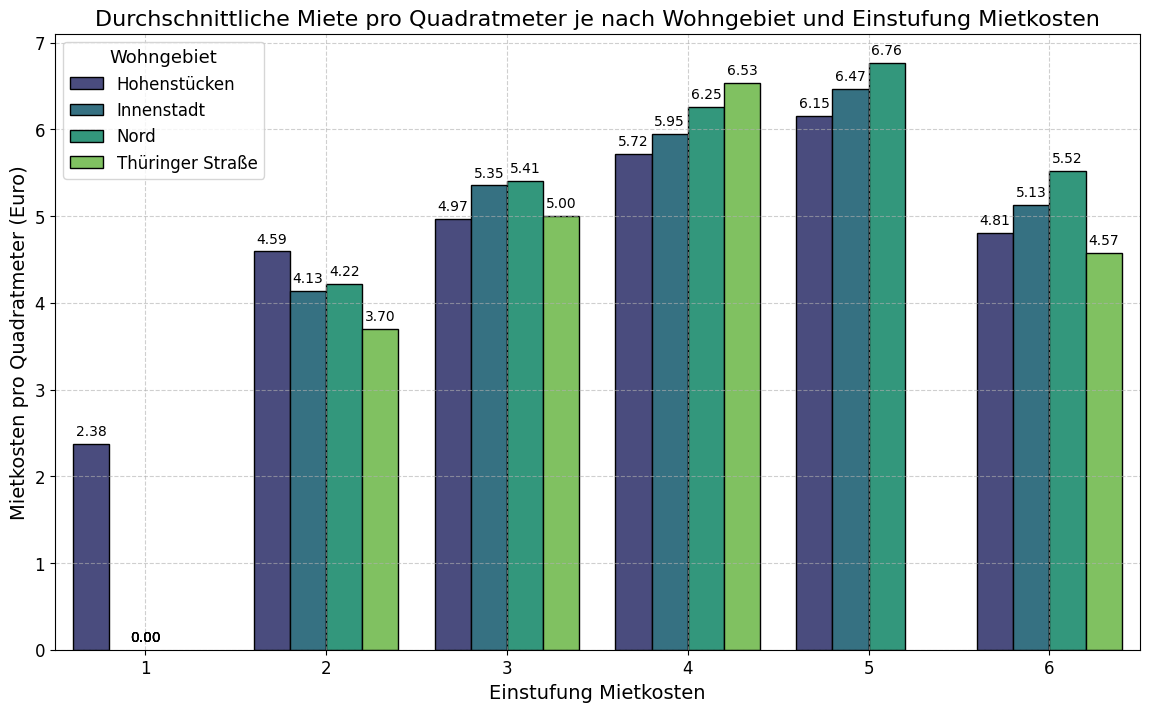

In [20]:
# Boxplot der Mietkosten pro Quadratmeter nach Wohngebiet
# Durchschnittliche Miete pro Quadratmeter je nach Wohngebiet und Einstufung Mietkosten berechnen
result = (
    useful_df.groupby(["wohngebiet", "einstufung_mietkosten"])["mietkosten/m²"]
    .mean()
    .reset_index()
)

# Ergebnisse formatieren (ohne Nachkommastellen)
result["mietkosten/m²"] = result["mietkosten/m²"]

print(result.to_string(index=True))

# Clustered Bar Chart visualisieren mit mehr Details
plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(
    x="einstufung_mietkosten",
    y="mietkosten/m²",
    hue="wohngebiet",
    data=result,
    palette="viridis",
    ci=None,
    edgecolor="black",
)

# Balkenbeschriftungen hinzufügen
for p in bar_plot.patches:
    bar_plot.annotate(
        format(p.get_height(), ".2f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
    )

# Achsentitel und Beschriftungen anpassen
plt.title(
    "Durchschnittliche Miete pro Quadratmeter je nach Wohngebiet und Einstufung Mietkosten",
    fontsize=16,
)
plt.xlabel("Einstufung Mietkosten", fontsize=14)
plt.ylabel("Mietkosten pro Quadratmeter (Euro)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Wohngebiet", title_fontsize="13", fontsize="12")

# Gitter hinzufügen
plt.grid(True, linestyle="--", alpha=0.6)

# Diagramm anzeigen
plt.show()

Das oberen Balkendiagramm zeigt die durchschnittlichen Mietkosten pro Quadratmeter in verschiedenen Wohngebieten und Mietkostenkategorien. Der Grafik zufolge ist es auffällig, dass die erste Kategorie von Mietenkosten nur in Hohenstücken zu finden ist. Nord hat in den höheren Einstufungen die höchsten Mietpreise, mit Spitzenwerten von bis zu 6,76 € pro Quadratmeter. Die Innenstadt weist ebenfalls durchgehend hohe Mietkosten auf, besonders in den höheren Einstufungen, mit Preisen bis zu 6,47 € pro Quadratmeter. Hohenstücken zeigt vergleichsweise hohe Mietpreise, insbesondere in den höheren Kategorien, mit bis zu 6,15 € pro Quadratmeter. Thüringer Straße zeigt eine große Variabilität, mit Mietkosten von 3,70 € bis 6,53 € pro Quadratmeter. Einige Wohngebiete zeigen keine Mietkosten in bestimmten Kategorien, was auf Marktverfügbarkeit, Nachfrage und Angebot oder sozioökonomische zurückzuführen sein könnte. Politisch betrachtet deutet dies auf eine Ungleichverteilung hin: Wohlhabendere Gebiete wie die Innenstadt und Nord bieten hauptsächlich hochpreisige Wohnungen an, während sozial schwächere Gebiete wie die Thüringer Straße größere Preisvariabilität und niedrigere Mietkosten aufweisen. Zusammenfassend lässt sich sagen, dass die Mietkosten pro Quadratmeter je nach Wohngebiet variieren.

### **Korrelationsmatrix der Features**

 Ziel hier ist es, die Beziehung zwischen den verschiedenen Merkmalen (Features) im Datensatz zu visualisieren. Dadurch kann festgestellt werden, welche Features stark miteinander korreliert sind und welche weniger stark korreliert sind. Die Korrelationsmatrix basiert auf der zweiten Hypothese:
 **Das Vorhandensein von Ausstattungsmerkmalen wie Dusche, Badewanne, Aufzug, Balkon/Terrasse korreliert mit höheren Mietkosten pro Quadratmeter.**

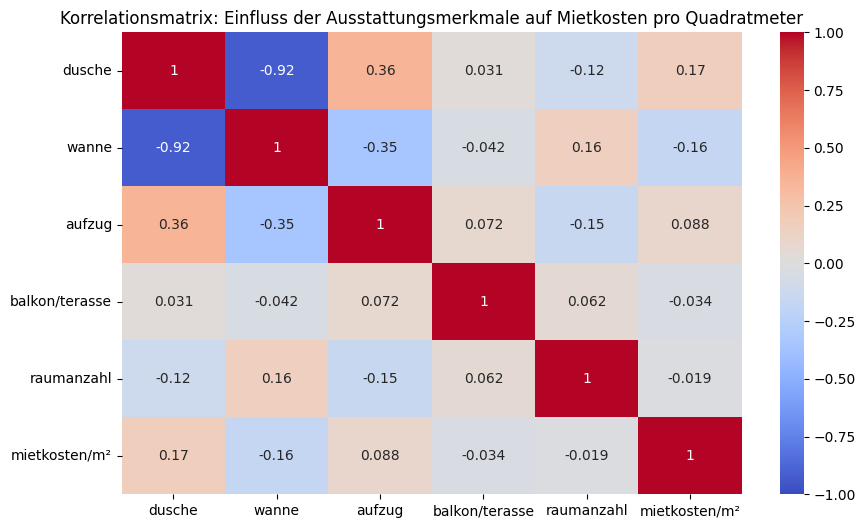

In [21]:
# Berechnung der Korrelationen
correlation_matrix = useful_df[
    ["dusche", "wanne", "aufzug", "balkon/terasse", "raumanzahl", "mietkosten/m²"]
].corr()

# Erstellung der Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(
    "Korrelationsmatrix: Einfluss der Ausstattungsmerkmale auf Mietkosten pro Quadratmeter"
)
plt.show()

1. **Dusche**:
   - **Korrelation mit Mietkosten/m²: 0.17**
   - **Interpretation**: Es besteht eine moderate positive Korrelation. Das bedeutet, dass Wohnungen mit Duschen tendenziell höhere Mietkosten pro Quadratmeter haben. Wenn eine Wohnung eine Dusche hat, kann dies als ein Merkmal betrachtet werden, das den Mietpreis leicht erhöht.

2. **Wanne**:
   - **Korrelation mit Mietkosten/m²: -0.16**
   - **Interpretation**: Es besteht eine moderate negative Korrelation. Wohnungen mit Badewannen neigen dazu, niedrigere Mietkosten pro Quadratmeter zu haben. Das Vorhandensein einer Badewanne scheint somit nicht attraktiv genug zu sein, um den Mietpreis zu erhöhen, und kann sogar zu einer geringfügigen Senkung führen.

3. **Aufzug**:
   - **Korrelation mit Mietkosten/m²: 0.088**
   - **Interpretation**: Es gibt eine schwache positive Korrelation. Ein Aufzug hat einen sehr geringen Einfluss auf die Erhöhung der Mietkosten pro Quadratmeter. Das Vorhandensein eines Aufzugs könnte den Mietpreis leicht erhöhen, ist aber kein entscheidender Faktor.

4. **Balkon/Terrasse**:
   - **Korrelation mit Mietkosten/m²: -0.034**
   - **Interpretation**: Es gibt eine sehr schwache negative Korrelation. Das Vorhandensein eines Balkons oder einer Terrasse hat kaum Einfluss auf die Mietkosten pro Quadratmeter und kann tendenziell zu einer minimalen Senkung der Mietpreise führen. Dies könnte darauf hindeuten, dass Balkone oder Terrassen zwar wünschenswert, aber nicht ausschlaggebend für die Mietpreisgestaltung sind.

5. **Raumanzahl**:
   - **Korrelation mit Mietkosten/m²: -0.019**
   - **Interpretation**: Es gibt eine sehr schwache negative Korrelation. Mehr Räume in einer Wohnung sind tendenziell mit leicht niedrigeren Mietkosten pro Quadratmeter verbunden. Dies könnte darauf hinweisen, dass größere Wohnungen (mit mehr Räumen) pro Quadratmeter etwas günstiger sind.

Die Hypothese war, dass Ausstattungsmerkmale wie Dusche, Wanne, Aufzug und Balkon/Terrasse typischerweise mit höheren Mietkosten pro Quadratmeter korrelieren.

- **Dusche** und **Aufzug** zeigen eine positive Korrelation mit den Mietkosten, wobei die Dusche einen moderaten und der Aufzug einen schwachen positiven Einfluss hat.
- **Wanne**, **Balkon/Terrasse** und **Raumanzahl** zeigen negative Korrelationen, wobei die Wanne einen moderaten und Balkon/Terrasse sowie Raumanzahl sehr schwache negative Einflüsse auf die Mietkosten pro Quadratmeter haben.

Die Hypothese trifft daher nur teilweise zu. Während einige Ausstattungsmerkmale wie Duschen und Aufzüge tendenziell mit höheren Mietkosten korrelieren, zeigen andere Merkmale wie Wannen, Balkone/Terrassen und die Anzahl der Räume entweder keine oder sogar eine negative Korrelation mit den Mietkosten pro Quadratmeter.

### **Hypothese 3: Wohnungen, in denen Mieter bereits länger wohnen, haben möglicherweise niedrigere Mietkosten pro Quadratmeter im Vergleich zu Wohnungen mit kürzerer Wohndauer.**

da die Mietkosten pro Quadratmeter von Wohngebiet zu Wohngebiet variieren, haben wir das Wohngebiet „Nord“ als Beispiel für diese Übung verwendet, um die Hypothese zu überprüfen, dass die Mietkosten pro Quadratmeter mit der Wohndauer des Wohnsitzes variieren. Zu diesem Zweck haben wir auch eine Kategorie erstellt, indem wir jeder Kategorie ein Intervall von 100 Monaten zugewiesen haben.

/tmp/ipykernel_14565/1877297406.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(50, len(x)), random_state=42))
/tmp/ipykernel_14565/1877297406.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


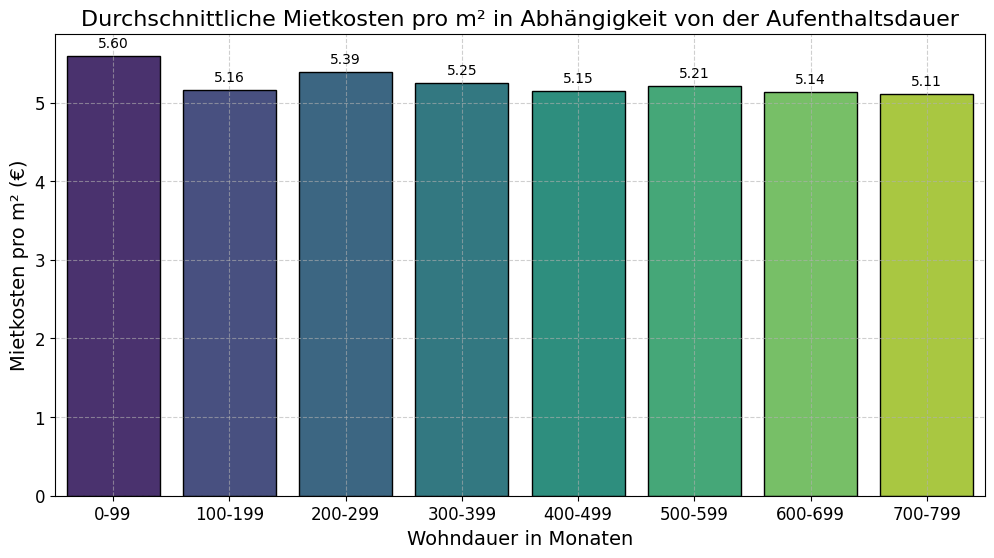

In [22]:
# Definieren der Intervalle und Labels für die Aufenthaltsdauer
bins = range(0, df["wohndauer_in_monaten"].max() + 50, 100)
labels = [f"{i}-{i+99}" for i in bins[:-1]]

# Erstellen der Spalte 'wohndauer_kategorie'
df["wohndauer_kategorie"] = pd.cut(
    df["wohndauer_in_monaten"], bins=bins, labels=labels, right=False
)

# Filtern des DataFrames für 'wohngebiet' Nord und 'mietkosten' von 300
filtered_df = df[(df["wohngebiet"] == "Nord") & (df["mietkosten"] == 300)]

# Zufällige Auswahl von 50 Werten für jede Kategorie der Aufenthaltsdauer
sampled_df = (
    filtered_df.groupby("wohndauer_kategorie", observed=True)
    .apply(lambda x: x.sample(min(50, len(x)), random_state=42))
    .reset_index(drop=True)
)

# Berechnen der Summe der 'mietkosten' und der Summe der 'wohnfläche' für jede Kategorie
result = (
    sampled_df.groupby("wohndauer_kategorie", observed=True)
    .apply(
        lambda x: pd.Series(
            {
                "total_mietkosten": x["mietkosten"].sum(),
                "total_wohnfläche": x["wohnfläche"].sum(),
                "mietkosten_pro_m2": x["mietkosten"].sum() / x["wohnfläche"].sum(),
            }
        )
    )
    .reset_index()
)


# Visualisierung der Ergebnisse
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(
    x="wohndauer_kategorie",
    y="mietkosten_pro_m2",
    hue="wohndauer_kategorie",  # Assigning hue
    data=result,
    palette="viridis",
    edgecolor="black",
    legend=False,  # Hiding legend
)

# Beschriftung der Balken mit den Werten
for p in bar_plot.patches:
    bar_plot.annotate(
        format(p.get_height(), ".2f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
    )

# Anpassung der Achsen und Titel
plt.title(
    "Durchschnittliche Mietkosten pro m² in Abhängigkeit von der Aufenthaltsdauer",
    fontsize=16,
)
plt.xlabel("Wohndauer in Monaten", fontsize=14)
plt.ylabel("Mietkosten pro m² (€)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Der Grafik zufolge kann erkannt werden, dass die Mietkosten pro Quadrameter nach Wohndauer variieren. Je größer die Wohndauer ist, desto geringer wird die Mietkosten pro Quadrameter. wenn wir die Grafik betrachten, können wir bemerken, dass Bewohner mit einer Wohndauer zwischen [600-699] und [700-700] haben niedrige Mietkosten pro Quadrameter als Bewohner mit Wohndauer zwischen [500-599]. In der Grafik sehen wir zwei Ausnahmen, wie die Bewohner mit einer Wohndauer von 200-299, die etwas höher ist als die der Bewohner mit einer Wohndauer von 100-199. Dies könnte darauf zurückzuführen sein, dass die Wohnungen der Bewohner der Kategorien 100-199 vor ihrem Einzug nicht renoviert wurden, was bedeutet, dass die Miete nicht gestiegen ist.

Nach der Visualisierung und Überprüfung der Hypothesen werden wir uns nun auf das Trainieren und Evaluieren der Modelle konzentrieren.

# **Parameter für das Training und die Evaluation**

Um den Überlick zu erhalten, werden folgend die Parameter für die Modell-Trainigs und -Evaluationen definiert.


In [23]:
# Setze die Parameter
# =======================

# Für den Split in Trainings- und Testdaten
TEST_PROPORTION = 0.2  # Anteil an der Gesamtanzahl der Beobachtungen
SHUFFLE = True  # Zufällige Auswahl der Beobachtungen

FIT_INTERCEPT = True

# RIDGE_ALPHAS = 10 ** np.linspace(10, -2, 100) * 0.5
RIDGE_ALPHAS = np.linspace(0.1, 200, 100)  # HYPERPARAMETER


# Für Entscheidungsbaum (Hyperparameter-Tuning)
MAX_DEPTH = 4  # Maximale Tiefe des Baumes
CRITERION = "squared_error"
MIN_SAMPLES_SPLIT = (
    5  # Mindestanzahl an Beobachtungen in einem Node, damit ein Split durchgeführt wird
)
MIN_SAMPLES_LEAF = 3  # Mindestanzahl an Beobachtungen in einem Blatt
MAX_FEATURES = (
    None  # Anzahl der Features, die für den besten Split berücksichtigt werden
)
CCP_ALPHA = (
    0.0  # Minimaler Cost-Complexity Pruning Parameter, If 0, no pruning is performed
)
CV_STRATEGY = 5  # Number of splits for the cross-validation

## **Train-Test Split**

Wir teilen die Daten in Trainings- und Testdaten auf. Die Trainingsdaten werden verwendet, um das Modell zu trainieren, während die Testdaten verwendet werden, um die Leistung des Modells _out-of-sample_ zu evaluieren.

Das Modul `train_test_split` aus `sklearn.model_selection` wird verwendet, um die Daten aufzuteilen.
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_PROPORTION, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (4956, 18)
y_train: (4956,)
X_test: (1239, 18)
y_test: (1239,)


In unserer Arbeit werden wir das lineares Regressionsmodell (Um den linearen Zusammenhang zwischen den Variablen zu untersuchen) und Random Forest Regressionsmodell(Um nicht-lineare Zusammenhänge zu erfassen und die wichtigsten Einflussfaktoren zu identifizieren) und beide auf Testdaten evaluiert.

In [25]:
# Modelle initialisieren
modelLr = LinearRegression(fit_intercept=FIT_INTERCEPT)
modelRf = RandomForestRegressor(random_state=42)

useful_df.describe(include="all")

,wohngebiet,wohnfläche,raumanzahl,dusche,wanne,aufzug,balkon/terasse,einstufung_mietkosten,mietkosten,mietkosten/m²
count,6195,6195.000000,6195.000000,6195.0,6195.0,6195.0,6195.0,6195.000000,6195.000000,6195.000000
unique,4,NaN,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN
top,Nord,NaN,NaN,0.0,1.0,0.0,1.0,NaN,NaN,NaN
freq,3327,NaN,NaN,3858.0,4010.0,5209.0,6028.0,NaN,NaN,NaN
mean,NaN,58.527049,2.664084,NaN,NaN,NaN,NaN,3.039548,303.039548,5.178552
std,NaN,12.479818,0.720559,NaN,NaN,NaN,NaN,0.819061,80.309043,0.902850
min,NaN,28.380000,1.000000,NaN,NaN,NaN,NaN,1.000000,75.000000,1.226894
25%,NaN,49.680000,2.000000,NaN,NaN,NaN,NaN,3.000000,300.000000,4.753981
50%,NaN,59.030000,3.000000,NaN,NaN,NaN,NaN,3.000000,300.000000,5.071851
75%,NaN,61.130000,3.000000,NaN,NaN,NaN,NaN,3.000000,300.000000,5.846244


## **In-Sample Prognoseperformance:**
 wir werden mit In sample Prognoseperformance arbeiten

**Definition**: Die In-Sample Prognoseperformance wird anhand der Daten bewertet, die zur Trainierung des Modells verwendet wurden.

**Interpretation**: Die In-Sample Prognoseperformance gibt an, wie gut das Modell die Daten wiedergeben kann, mit denen es trainiert wurde.

**Vorteile**:
In-Sample Prognose performance bietet ermöglicht nicht nur die einfache Berechnung sondern auch die Analyse der Modellanpassung

## **OLS Regression**
#### Linear Regression: Einfache und leicht verständliche Methode für lineare Zusammenhänge.
Im Folgenden werden wir eine OLS Regression durchführen. Dies dient als Referenzpunkt für die Regularisierungsverfahren, die wir später anwenden werden.

In [26]:
# Model trainieren
modelLr.fit(X_train, y_train)
yhat_test = modelLr.predict(X_test)
# In-Sample Vorhersage für Trainingsdaten
yhat = modelLr.predict(X_train)
# Berechnung der Leistungskennzahlen
mae_rg = mean_absolute_error(y_train, yhat)  # Mean Absolute Error für Trainingsdaten
medae_rg = median_absolute_error(
    y_train, yhat
)  # Median Absolute Error für Trainingsdaten
r2_lr = r2_score(y_train, yhat)  # R²-Score für Trainingsdaten
rmse_lr = mean_squared_error(y_test, yhat_test, squared=False)

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## **RandomForestRegressor**
#### - Random Forest Regressor: Ein nicht-lineares Modell, das robuste Vorhersagen durch Kombination mehrerer Entscheidungsbäume liefert und gut mit komplexeren Datensätzen umgehen kann.


In [27]:
# Model trainieren
modelRf.fit(X_train, y_train)

# In-sample prediction
yhat = modelRf.predict(X_train)
yhat_test = modelRf.predict(X_test)
mae_rf = mean_absolute_error(y_train, yhat)
medae_rf = median_absolute_error(y_train, yhat)
r2_rf = r2_score(y_train, yhat)
rmse_rf = mean_squared_error(y_test, yhat_test, squared=False)

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Die Wichtigkeit der Features im Random Forest Modell wird dargestellt.
Um zu verstehen, welche Merkmale den größten Einfluss auf die Mietkosten haben.

In [28]:
# Feature Importance
importances_rf = modelRf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

Die Ergebnisse der Modelle (R², RMSE, MAE) werden zusammengefasst.
es geht um die Modellleistung zu bewerten und zu vergleichen.

/tmp/ipykernel_14565/3150286024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modell", y="R²", data=results_df, palette="viridis")
/tmp/ipykernel_14565/3150286024.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modell", y="RMSE", data=results_df, palette="viridis")



Modellergebnisse Prognose:
                     Modell        R²          RMSE           MAE         MedAE
0        Lineare Regression  1.000000  8.134885e-14  7.741252e-14  7.815970e-14
1  Random Forest Regression  0.999927  2.842364e-03  3.455328e-04  7.993606e-15


/tmp/ipykernel_14565/3150286024.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modell", y="MAE", data=results_df, palette="viridis")
/tmp/ipykernel_14565/3150286024.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modell", y="MedAE", data=results_df, palette="viridis")


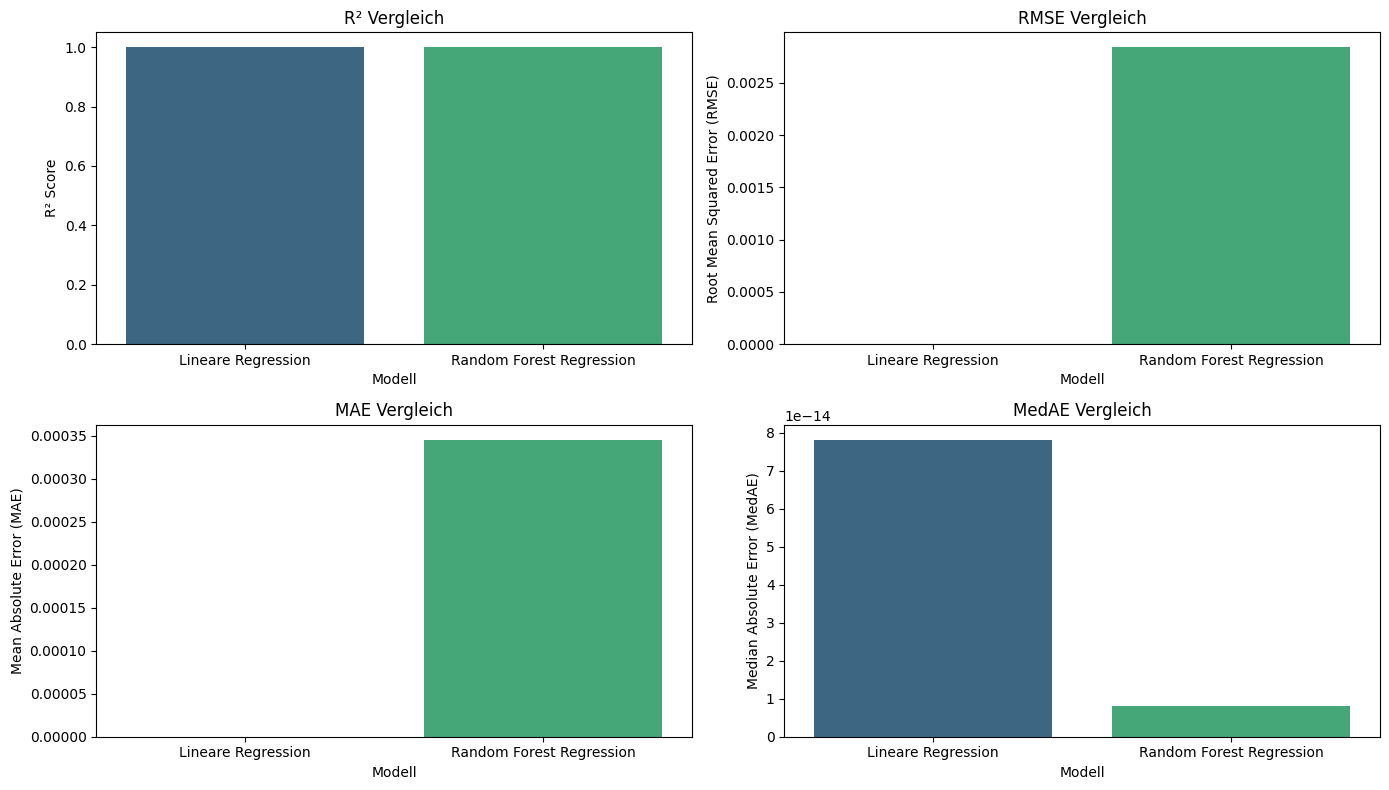

In [29]:
# Ergebnisse
results = {
    "Modell": ["Lineare Regression", "Random Forest Regression"],
    "R²": [r2_lr, r2_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_rg, mae_rf],
    "MedAE": [medae_rg, medae_rf],
}
results_df = pd.DataFrame(results)
print("\nModellergebnisse Prognose:")
print(results_df.to_string(index=True))


# Visualisierung der Ergebnisse
plt.figure(figsize=(14, 8))

# Subplot für R²
plt.subplot(2, 2, 1)
sns.barplot(x="Modell", y="R²", data=results_df, palette="viridis")
plt.title("R² Vergleich")
plt.ylabel("R² Score")

# Subplot für RMSE
plt.subplot(2, 2, 2)
sns.barplot(x="Modell", y="RMSE", data=results_df, palette="viridis")
plt.title("RMSE Vergleich")
plt.ylabel("Root Mean Squared Error (RMSE)")

# Subplot für MAE
plt.subplot(2, 2, 3)
sns.barplot(x="Modell", y="MAE", data=results_df, palette="viridis")
plt.title("MAE Vergleich")
plt.ylabel("Mean Absolute Error (MAE)")

# Subplot für MedAE
plt.subplot(2, 2, 4)
sns.barplot(x="Modell", y="MedAE", data=results_df, palette="viridis")
plt.title("MedAE Vergleich")
plt.ylabel("Median Absolute Error (MedAE)")

plt.tight_layout()
plt.show()

### **Interpretation der Ergebnisse:**

Die Ergebnisse der beiden Modelle, der linearen Regression und der Random Forest Regression, zeigen beeindruckende Leistungskennzahlen. Hier ist eine detaillierte Interpretation der Modellergebnisse:

#### Lineare Regression:

- **R² (Bestimmtheitsmaß):** Ein R² von 1.000000 bedeutet, dass das Modell 100% der Variabilität in den Mietkosten/m² erklärt. Dies ist ein perfekter Fit, was in der Realität selten vorkommt und möglicherweise auf Overfitting hinweist.

- **RMSE (Root Mean Squared Error):** Der RMSE-Wert ist \(8.134885 \times 10^{-14}\) EUR/m², was extrem nahe bei null liegt. Ein so geringer Wert deutet darauf hin, dass die Vorhersagen des Modells nahezu perfekt mit den tatsächlichen Werten übereinstimmen.

- **MAE (Mean Absolute Error):** Der MAE beträgt \(7.741252 \times 10^{-14}\) EUR/m², was ebenfalls extrem niedrig ist und auf sehr genaue Vorhersagen hinweist.

- **Median Absolute Error:** Der Median Absolute Error beträgt \(7.815970 \times 10^{-14}\) EUR/m², was die zentrale Tendenz der Abweichungen zwischen den vorhergesagten und den tatsächlichen Werten sehr klein zeigt.

#### Random Forest Regression:

- **R² (Bestimmtheitsmaß):** Ein R² von 0.999927 bedeutet, dass das Modell 99.9927% der Variabilität in den Mietkosten/m² erklärt. Dies ist ebenfalls ein sehr hoher Wert und deutet auf eine sehr gute Modellanpassung hin.

- **RMSE (Root Mean Squared Error):** Der RMSE-Wert beträgt \(2.842364 \times 10^{-3}\) EUR/m², was ebenfalls sehr gering ist und auf präzise Vorhersagen des Modells hinweist.

- **MAE (Mean Absolute Error):** Der MAE beträgt \(3.455328 \times 10^{-4}\) EUR/m², was ein weiteres Indiz für die hohe Genauigkeit der Vorhersagen ist.

- **Median Absolute Error:** Der Median Absolute Error beträgt \(7.993606 \times 10^{-15}\) EUR/m², was die zentrale Tendenz der Abweichungen sehr gering zeigt.

 Fazit:

Beide Modelle zeigen außergewöhnlich gute Ergebnisse, wobei die lineare Regression einen perfekten Fit aufweist. Allerdings sollte man bei einem perfekten R²-Wert immer vorsichtig sein, da dies oft auf Overfitting hinweisen kann, insbesondere bei kleinen Datensätzen.

Der Random Forest Regression ist ebenfalls extrem genau und bietet den Vorteil, dass es weniger anfällig für Overfitting ist im Vergleich zur linearen Regression. Beide Modelle sind in diesem Fall sehr leistungsfähig, und die Wahl des Modells könnte von anderen Faktoren wie Interpretierbarkeit und Robustheit gegen Overfitting abhängen.

### **Helper function**

In [30]:
def compute_performance(model, X_test, y_test):
    """
    Compute the performance metrics for a given model.

    Parameters:
    model (object): The trained model object.
    X_test (array-like): The input features for testing.
    y_test (array-like): The true target values for testing.

    Returns:
    mse (float): The mean squared error.
    mape (float): The mean absolute percentage error.
    """
    # Sage die Zielvariable für unbekannte Daten voraus
    y_pred = model.predict(X_test)
    # Berechne die Leistungskennzahlen
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    return mse, mape

# **Entscheidungsbaum für Regressionsprobleme**

Wir verwenden die Klasse `DecisionTreeRegressor` aus dem Modul `tree` von `sklearn` um einen Entscheidungsbaum für ein Regressionsproblem zu erstellen.

Details zu der Klasse ist hier zu finden: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

Weitere Informationen zu Entscheidungsbäumen ist hier zu finden: https://scikit-learn.org/stable/modules/tree.html#tree

In [31]:
# Initialisiere das Modell
tree = DTR(
    random_state=42,
    max_depth=MAX_DEPTH,
    criterion=CRITERION,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    max_features=MAX_FEATURES,
    ccp_alpha=CCP_ALPHA,
)


tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=3, min_samples_split=5,
                      random_state=42)

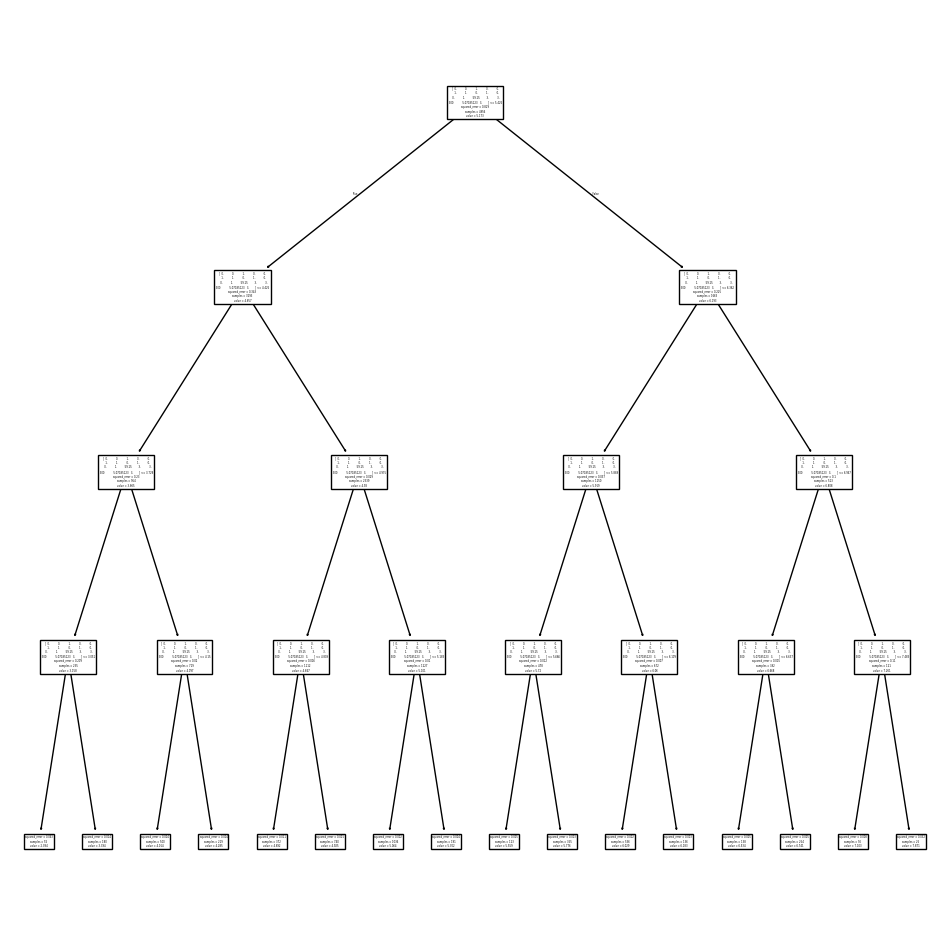

In [32]:
ax = subplots(figsize =(12 ,12))[1]
plot_tree(tree, feature_names=X_train, ax=ax);

## **Kreuzvalidierung ohne Pruning**

In [33]:
cross_val_score(tree, X_train, y_train, cv=5)

array([0.99433976, 0.99247823, 0.99452386, 0.99439612, 0.99393601])

## **Kreuzvalidierung mit Pruning**
Nun wollen wir testen, ob die Kreuzvalidierung mit Pruning die Leistung des Modells verbessert.

In [34]:
# Berechne den Kostenkomplexitäts-Beschnittpfad
ccp_path = tree.cost_complexity_pruning_path(X_train, y_train)

# Rufe die Werte für Alpha ab
parameters = {"ccp_alpha": ccp_path.ccp_alphas}

tree_grid = GridSearchCV(tree, parameters, refit=True, cv=CV_STRATEGY)

tree_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3,
                                             min_samples_split=5,
                                             random_state=42),
             param_grid={'ccp_alpha': array([0.00000000e+00, 5.22616146e-04, 7.68745353e-04, 8.65698154e-04,
       1.85059510e-03, 2.26005717e-03, 2.36227557e-03, 2.70551130e-03,
       6.50859727e-03, 6.57279694e-03, 7.60060288e-03, 8.68280049e-03,
       3.15042918e-02, 5.65685488e-02, 1.69919438e-01, 5.25953829e-01])})

Behalte die durch Kreuzvalidierung optimierten Ergebnisse und mache Vorhersagen für unbekannte Daten:

In [35]:
best_ = tree_grid.best_estimator_

# Sage die Zielvariable für unbekannte Daten voraus
fc_tree_oos = best_.predict(X_test)
fcerror_tree_oos = y_test - fc_tree_oos

# Berechne die Leistungskennzahlen
mse, mape = compute_performance(best_, X_test, y_test)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Percentage Error: {mape}")
fcerror_tree_oos.describe().round(2)

Mean Squared Error: 0.004115113068335907
Mean Absolute Percentage Error: 0.010355607424148372


count    1239.00
mean       -0.00
std         0.06
min        -0.26
25%        -0.04
50%         0.01
75%         0.04
max         0.26
Name: mietkosten/m², dtype: float64

### Interpretation der Ergebnisse

#### 1. **Mean Squared Error (MSE)**
- **Ergebnis**: `0.004115113068335907`
- **Interpretation**: Der Mean Squared Error (MSE) ist ein Maß dafür, wie stark die vorhergesagten Werte von den tatsächlichen Werten abweichen. Ein MSE von `0.0041` deutet darauf hin, dass die durchschnittliche quadratische Abweichung zwischen den vorhergesagten und den tatsächlichen Werten sehr gering ist. Dies bedeutet, dass das Modell sehr genau ist.

#### 2. **Mean Absolute Percentage Error (MAPE)**
- **Ergebnis**: `0.010355607424148372`
- **Interpretation**: Der Mean Absolute Percentage Error (MAPE) gibt die durchschnittliche prozentuale Abweichung zwischen den vorhergesagten und den tatsächlichen Werten an. Ein MAPE von `1.04%` bedeutet, dass die Vorhersagen des Modells im Durchschnitt nur um `1.04%` von den tatsächlichen Werten abweichen. Dies zeigt, dass das Modell eine hohe Vorhersagegenauigkeit hat.

#### 3. **Fehleranalyse (fcerror_tree_oos.describe().round(2))**
- **count**: `1239.00` (Anzahl der Testbeispiele)
- **mean**: `-0.00` (Durchschnittlicher Fehler, nahe bei Null, was gut ist)
- **std**: `0.06` (Standardabweichung des Fehlers, zeigt, wie stark die Fehler variieren)
- **min**: `-0.26` (Größter negativer Fehler)
- **25%**: `-0.04` (25% der Fehler sind kleiner als `-0.04`)
- **50% (Median)**: `0.01` (Die Hälfte der Fehler ist kleiner als `0.01`)
- **75%**: `0.04` (75% der Fehler sind kleiner als `0.04`)
- **max**: `0.26` (Größter positiver Fehler)

- **Interpretation**:
  - Der durchschnittliche Fehler (`mean`) ist nahezu Null, was darauf hinweist, dass das Modell weder systematisch überschätzt noch unterschätzt.
  - Die Standardabweichung (`std`) von `0.06` ist relativ klein, was bedeutet, dass die Fehlerwerte eng um den Durchschnittswert gruppiert sind.
  - Die minimalen und maximalen Fehler (`min` und `max`) liegen beide bei `-0.26` und `0.26`, was darauf hinweist, dass die extremsten Fehler nur geringfügig abweichen.
  - Die Quartile (`25%`, `50%`, `75%`) zeigen, dass die Mehrheit der Fehler relativ klein ist, mit den meisten Fehlern zwischen `-0.04` und `0.04`.

### Fazit
Das Modell zeigt eine hohe Vorhersagegenauigkeit, was durch den niedrigen Mean Squared Error und den niedrigen Mean Absolute Percentage Error belegt wird. Die Fehleranalyse bestätigt, dass die Fehlerwerte klein und gleichmäßig verteilt sind, ohne signifikante Ausreißer. Dies bedeutet, dass das Modell zuverlässig und präzise Vorhersagen für die Mietkosten pro Quadratmeter macht.

## **Zusammenfassung**

Das Ziel unserer Arbeit war die Analyse des WBG-Datensatzes mit Fokus auf die Mietkosten pro Quadratmeter als Zielvariable. Wir untersuchten, wie Raumanzahl, Wohngebiete, Ausstattung der Wohnung (Dusche, Wanne, Balkon, Geschoss) und Wohndauer diese Kosten beeinflussen. Nach Datenaufbereitung und -bereinigung, einschließlich der Berechnung der Mietkosten pro Quadratmeter, führten wir eine deskriptive Statistik und Visualisierung durch. Dabei stellten wir fest, dass die Mietkosten stark von Wohngebiet, Ausstattung und Wohndauer abhängen. Schließlich trainierten wir Modelle mit linearer Regression und Random Forest Regression, die zeigten, dass diese Merkmale gute Prädiktoren für die Mietkosten pro Quadratmeter sind.Dazu haben wir auch einen Entscheidungsbaum verwendet, um die Effizienz und Güte des Modells bei der Vorhersage zu überprüfen.